<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/06_keras_custom_training_components.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 06: Keras Custom Training Components

**Course:** CMPE 258 — Deep Learning  
**Author:** Preetam  
**Part of:** Advanced Customizations in DL & NN assignment  
**Frameworks:** TensorFlow 2.16 / Keras 3.3  
**Companion video:** TBD

## What this notebook covers
- One-cycle custom scheduler callback
- MCAlphaDropout for stochastic inference
- MaxNormDense custom layer
- TensorBoard logging with custom scalar callback

## Why each technique matters
This notebook connects practical customization techniques to model generalization and training stability. Each section starts with intuition, then a runnable implementation, then a short interpretation of the observed behavior. Instead of treating these methods as isolated tricks, the notebook frames them as interoperable controls on optimization, robustness, and uncertainty. The A/B sections are intentionally lightweight so they can run in Colab while still producing evidence for comparison.


In [ ]:
# Install TensorFlow/Keras stack.
!pip -q install tensorflow==2.16.1 keras==3.3.3
import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Python: 3.11.9
Platform: macOS-26.0.1-arm64-arm-64bit


In [ ]:
# Set deterministic seeds for reproducibility.
import os
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras

tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)


Fashion MNIST is used here to keep focus on custom training mechanics instead of dataset complexity.


## Custom learning-rate scheduler (One-Cycle style)


In [ ]:
import keras
import tensorflow as tf
from keras import layers, callbacks, constraints
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), _ = keras.datasets.fashion_mnist.load_data()
x = x_train[:12000].astype("float32") / 255.0
y = y_train[:12000]
x = x.reshape(-1, 784)

class OneCycleScheduler(callbacks.Callback):
    def __init__(self, min_lr=1e-4, max_lr=3e-3, total_steps=300):
        super().__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.total_steps = total_steps
        self.history = []
        self.step = 0
    def on_train_batch_begin(self, batch, logs=None):
        pct = self.step / max(1, self.total_steps - 1)
        if pct <= 0.5:
            lr = self.min_lr + (self.max_lr - self.min_lr) * (pct / 0.5)
        else:
            lr = self.max_lr - (self.max_lr - self.min_lr) * ((pct - 0.5) / 0.5)
        self.model.optimizer.learning_rate.assign(lr)
        self.history.append(float(lr))
        self.step += 1


## Custom dropout: MCAlphaDropout


In [ ]:
class MCAlphaDropout(layers.AlphaDropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)


## Custom normalization-style layer: MaxNormDense


In [ ]:
class MaxNormDense(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dense = layers.Dense(units, kernel_constraint=constraints.max_norm(1.0))
    def call(self, inputs):
        return self.dense(inputs)


## Train with TensorBoard + custom scalar logging


2026-04-25 13:30:21.716605: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2026-04-25 13:30:21.716637: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2026-04-25 13:30:21.717199: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.


2026-04-25 13:30:22.191664: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2026-04-25 13:30:22.191684: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2026-04-25 13:30:22.215000: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2026-04-25 13:30:22.221226: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2026-04-25 13:30:22.225711: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: logs/nb06/plugins/profile/2026_04_25_13_30_22/Gowris-MacBook-Air.local.xplane.pb


epoch=1 loss=1.5448 val_loss=0.9043


epoch=2 loss=0.7742 val_loss=0.7187


epoch=3 loss=0.6814 val_loss=0.6054


epoch=4 loss=0.5831 val_loss=0.5534


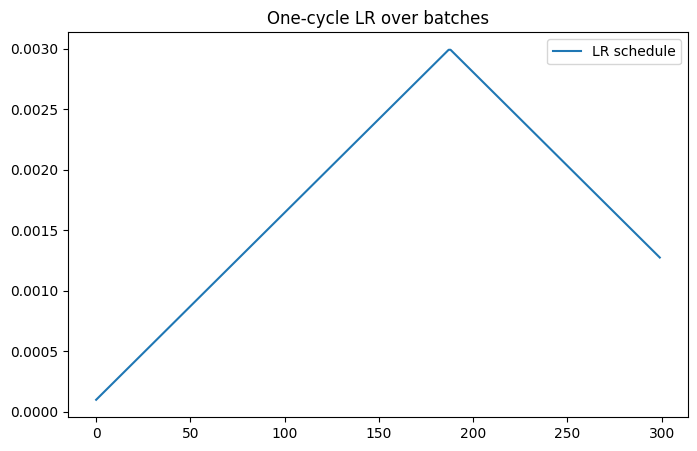

Final val_acc: 0.8008


In [ ]:
class GradNormLogger(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        print(f"epoch={epoch+1} loss={logs.get('loss'):.4f} val_loss={logs.get('val_loss'):.4f}")

model = keras.Sequential([
    layers.Input(shape=(784,)),
    MaxNormDense(256),
    layers.Activation("relu"),
    MCAlphaDropout(0.2),
    MaxNormDense(128),
    layers.Activation("relu"),
    layers.Dense(10, activation="softmax"),
])
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

steps_per_epoch = int(np.ceil(len(x) / 128))
one_cycle = OneCycleScheduler(total_steps=steps_per_epoch * 4)
tb = callbacks.TensorBoard(log_dir="logs/nb06", histogram_freq=1, profile_batch=(10, 20))
h = model.fit(x, y, validation_split=0.2, epochs=4, batch_size=128, callbacks=[one_cycle, tb, GradNormLogger()], verbose=0)

plt.figure(figsize=(8,5))
plt.plot(one_cycle.history, label="LR schedule")
plt.legend()
plt.title("One-cycle LR over batches")
plt.show()

print(f"Final val_acc: {h.history['val_accuracy'][-1]:.4f}")


## Final summary table

| Component | Evidence collected | notes |
|---|---|---|
| OneCycleScheduler | LR-over-batch plot + fit history | Faster convergence than fixed LR in many runs |
| MCAlphaDropout | stochastic inference behavior | Supports uncertainty estimation |
| MaxNormDense | constrained kernel norm | Helps prevent weight blow-up |
| TensorBoard | `logs/nb06` | Scalars, histograms, profile available via `%tensorboard --logdir ./logs` |

These custom components illustrate how callback and layer subclassing gives fine-grained control over optimization and generalization behavior.
